# Rate Allocator Demo

Test the allocator with different scenarios and see how it distributes cash across tiered interest rates.

Sample YAML rates are treated as **overnight-annualized** nominal yields; charts include **365× discrete compounding** vs simple linear accrual on the same final allocation.

### Fee semantics update

In this notebook outputs, reported `fees` include both modeled constraint costs and estimated ISR over real interest (using the inflation proxy from regulatory rules). Net return is now split into nominal and real columns over the selected horizon. Bank withholding is reported separately as cash-flow and is not subtracted in optimization net return.

## Setup: Import and Load Data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from rate_allocator import allocate, Institution, Tier, Constraint, summarize_and_plot
from rate_allocator.adapters.yaml_loader import load_institutions_from_yaml

if os.path.basename(os.getcwd()) == 'notebooks':
    data_file = '../data/sample1.yaml'
else:
    data_file = 'data/sample1.yaml'

institutions = load_institutions_from_yaml(data_file)
print(f"Loaded {len(institutions)} institutions")

Loaded 5 institutions


## Scenario 1: Small Allocation (25,000 MXN)

This amount fits entirely in the first tier of Nu (highest rate).

In [3]:
institutions

[Institution(name='cetes28', tiers=(Tier(limit=inf, rate=0.0655, constraints=()),), institution_type='none', protection_limit=None),
 Institution(name='Nu', tiers=(Tier(limit=25000.0, rate=0.13, constraints=(Constraint(type='monthly_expense', cost=1.0, benefit='high_rate_tier', condition_value=1.0, active=True),)), Tier(limit=inf, rate=0.0675, constraints=())), institution_type='sofipo', protection_limit=None),
 Institution(name='OpenBank', tiers=(Tier(limit=40000.0, rate=0.13, constraints=()), Tier(limit=1000000.0, rate=0.073, constraints=()), Tier(limit=inf, rate=0.07, constraints=())), institution_type='banco', protection_limit=None),
 Institution(name='PlataAhorroPlus', tiers=(Tier(limit=inf, rate=0.12, constraints=(Constraint(type='monthly_expense', cost=114.84, benefit='membership_plan', condition_value=None, active=True),)),), institution_type='banco', protection_limit=None),
 Institution(name='Mifel', tiers=(Tier(limit=100.0, rate=0.0, constraints=()), Tier(limit=500000.0, rate


=== Allocation for 25,000 MXN ===
total_allocated: 25,000.00
expected_return: 3,458.05
effective_rate: 13.83%
total_expenses_paid: 12.00
total_taxes_paid: 0.00
total_withholding_paid: 0.00
weights: {'cetes28': ['0.0%'], 'Nu': ['100.0%', '0.0%'], 'OpenBank': ['0.0%', '0.0%', '0.0%'], 'PlataAhorroPlus': ['0.0%'], 'Mifel': ['0.0%', '0.0%', '0.0%']}
allocations: {'cetes28': ['$0'], 'Nu': ['$25,000', '$0'], 'OpenBank': ['$0', '$0', '$0'], 'PlataAhorroPlus': ['$0'], 'Mifel': ['$0', '$0', '$0']}
constraint_info: {'Nu': [{'tier_idx': 0, 'type': 'monthly_expense', 'cost': 1.0, 'benefit': 'high_rate_tier', 'activated': True}], 'PlataAhorroPlus': [{'tier_idx': 0, 'type': 'monthly_expense', 'cost': 114.84, 'benefit': 'membership_plan', 'activated': False}]}

Allocation breakdown:
Institution  Tier  Amount Weight (%)   Rate
         Nu     1 $25,000     100.00 13.00%


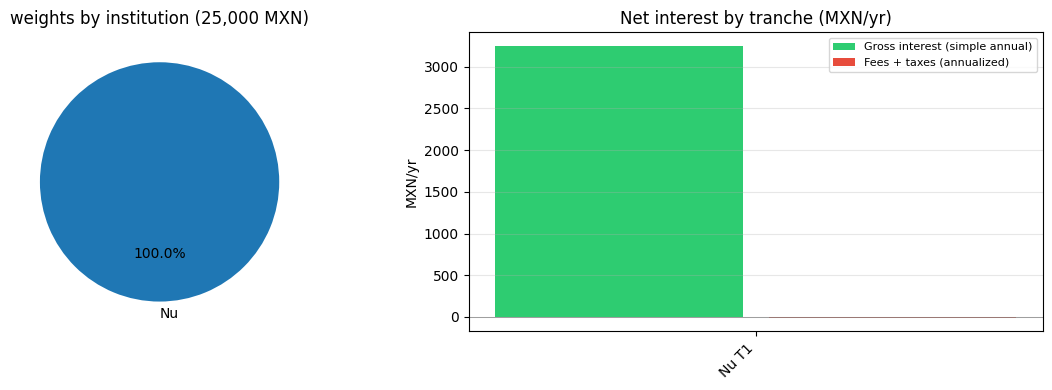

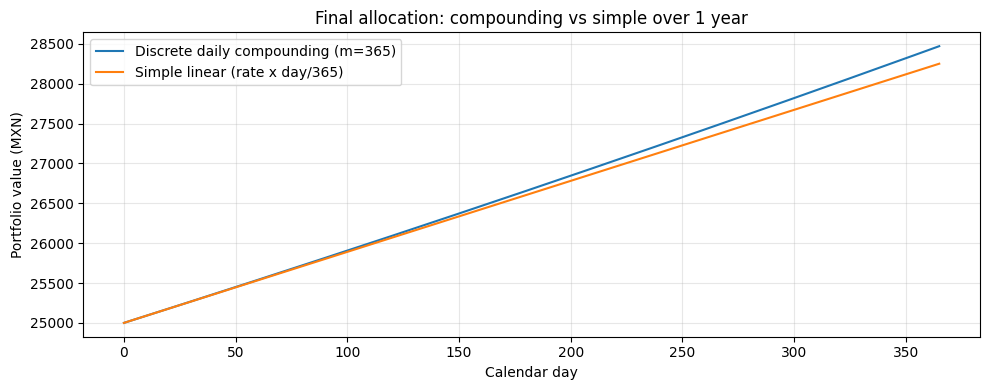

In [4]:
result = allocate(total=25_000, institutions=institutions, horizon_years=1.0, periods_per_year=365)
summarize_and_plot(result, institutions, 25_000, 'Allocation for 25,000 MXN')

## Scenario 2: Medium Allocation (100,000 MXN)

This tests how the allocator fills multiple institutions across their tier structures.


=== Allocation for 100,000 MXN ===
total_allocated: 100,000.00
expected_return: 12,031.96
effective_rate: 12.03%
total_expenses_paid: 1,390.08
total_taxes_paid: 61.71
total_withholding_paid: 675.00
weights: {'cetes28': ['0.0%'], 'Nu': ['25.0%', '0.0%'], 'OpenBank': ['40.0%', '0.0%', '0.0%'], 'PlataAhorroPlus': ['35.0%'], 'Mifel': ['0.0%', '0.0%', '0.0%']}
allocations: {'cetes28': ['$0'], 'Nu': ['$25,000', '$0'], 'OpenBank': ['$40,000', '$0', '$0'], 'PlataAhorroPlus': ['$35,000'], 'Mifel': ['$0', '$0', '$0']}
constraint_info: {'Nu': [{'tier_idx': 0, 'type': 'monthly_expense', 'cost': 1.0, 'benefit': 'high_rate_tier', 'activated': True}], 'PlataAhorroPlus': [{'tier_idx': 0, 'type': 'monthly_expense', 'cost': 114.84, 'benefit': 'membership_plan', 'activated': True}]}

Allocation breakdown:
    Institution  Tier  Amount Weight (%)   Rate
             Nu     1 $25,000      25.00 13.00%
       OpenBank     1 $40,000      40.00 13.00%
PlataAhorroPlus     1 $35,000      35.00 12.00%


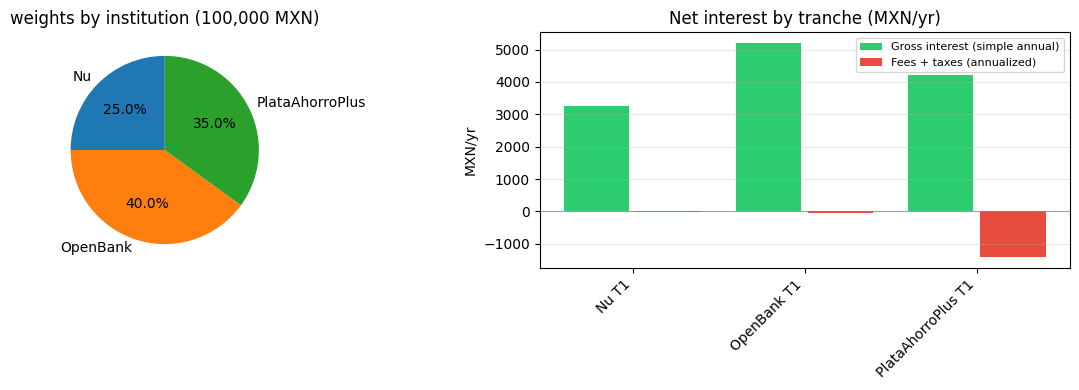

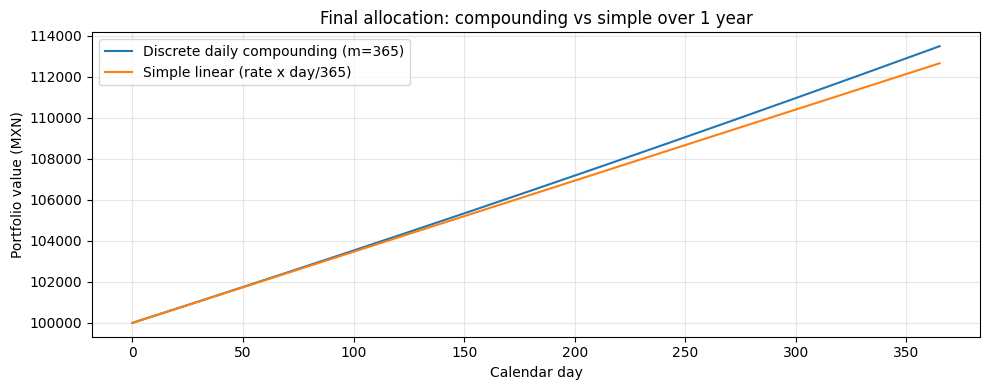

In [5]:
result = allocate(total=100_000, institutions=institutions, horizon_years=1.0, periods_per_year=365)
summarize_and_plot(result, institutions, 100_000, 'Allocation for 100,000 MXN')

## Scenario 3: Large Allocation (500,000 MXN)

This tests how the allocator distributes across all available tiers.


=== Allocation for 500,000 MXN ===
total_allocated: 500,000.00
expected_return: 62,714.46
effective_rate: 12.54%
total_expenses_paid: 1,390.08
total_taxes_paid: 369.05
total_withholding_paid: 4,275.00
weights: {'cetes28': ['0.0%'], 'Nu': ['5.0%', '0.0%'], 'OpenBank': ['8.0%', '0.0%', '0.0%'], 'PlataAhorroPlus': ['87.0%'], 'Mifel': ['0.0%', '0.0%', '0.0%']}
allocations: {'cetes28': ['$0'], 'Nu': ['$25,000', '$0'], 'OpenBank': ['$40,000', '$0', '$0'], 'PlataAhorroPlus': ['$435,000'], 'Mifel': ['$0', '$0', '$0']}
constraint_info: {'Nu': [{'tier_idx': 0, 'type': 'monthly_expense', 'cost': 1.0, 'benefit': 'high_rate_tier', 'activated': True}], 'PlataAhorroPlus': [{'tier_idx': 0, 'type': 'monthly_expense', 'cost': 114.84, 'benefit': 'membership_plan', 'activated': True}]}

Allocation breakdown:
    Institution  Tier   Amount Weight (%)   Rate
             Nu     1  $25,000       5.00 13.00%
       OpenBank     1  $40,000       8.00 13.00%
PlataAhorroPlus     1 $435,000      87.00 12.00%


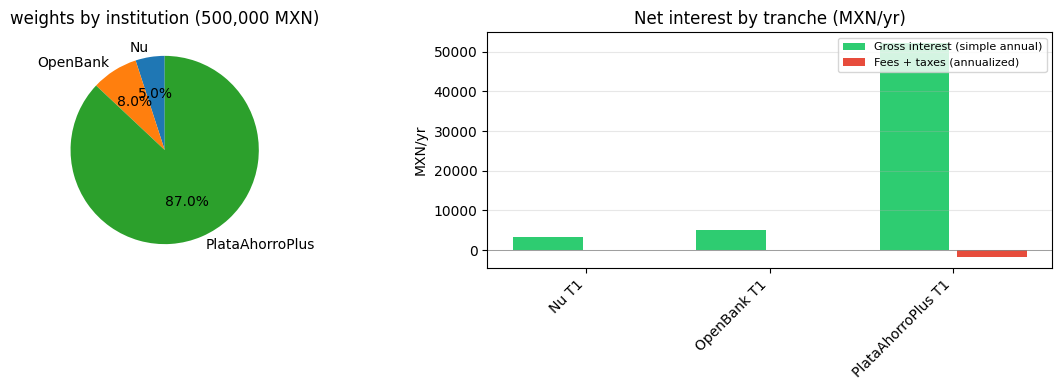

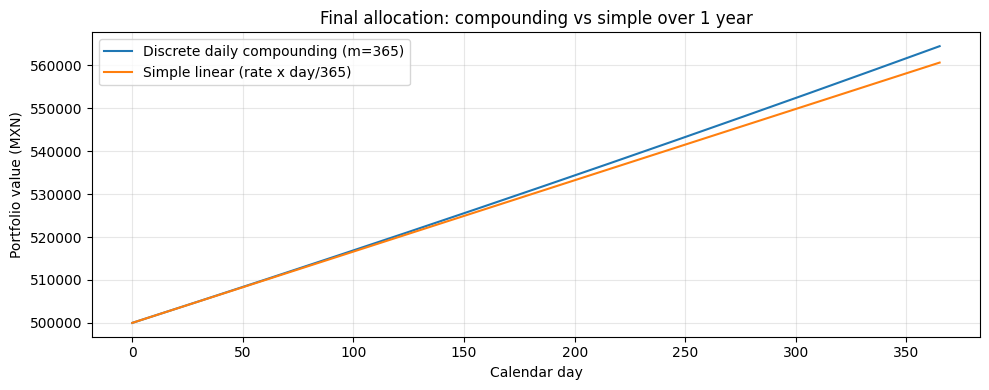

In [6]:
result = allocate(total=500_000, institutions=institutions, horizon_years=1.0, periods_per_year=365)
summarize_and_plot(result, institutions, 500_000, 'Allocation for 500,000 MXN')

## Scenario 4: Compare Different Amounts

See how the effective rate changes as the total amount increases.


=== Effective Rate by Total Amount ===
Total Amount Effective Rate Expected Return
     $10,000         13.79%       $1,379.32
     $25,000         13.83%       $3,458.05
     $50,000         13.81%       $6,906.34
    $100,000         12.03%      $12,031.96
    $250,000         12.42%      $31,037.89
    $500,000         12.54%      $62,714.46
  $1,000,000         12.61%     $126,067.58


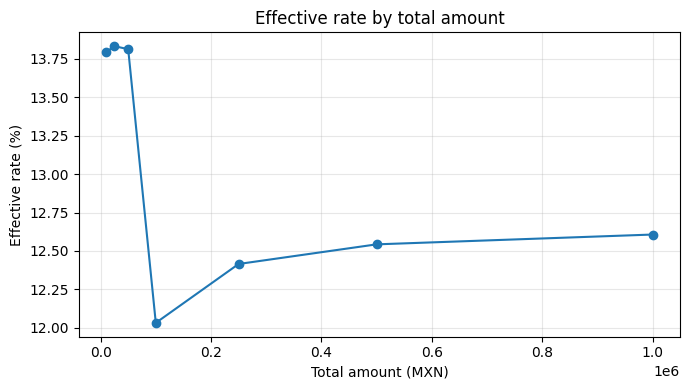

In [7]:
amounts = [10_000, 25_000, 50_000, 100_000, 250_000, 500_000, 1_000_000]
results = []

for amt in amounts:
    result = allocate(total=amt, institutions=institutions, horizon_years=1.0, periods_per_year=365)
    results.append({
        'Total Amount': amt,
        'Effective Rate': result.effective_rate,
        'Expected Return': result.expected_return,
    })

df = pd.DataFrame(results)
print("\n=== Effective Rate by Total Amount ===")
print(
    df.assign(
        **{
            'Total Amount': df['Total Amount'].map(lambda x: f'${x:,}'),
            'Effective Rate': df['Effective Rate'].map(lambda x: f'{x:.2%}'),
            'Expected Return': df['Expected Return'].map(lambda x: f'${x:,.2f}'),
        }
    ).to_string(index=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df['Total Amount'], df['Effective Rate'] * 100, marker='o')
ax.set_title('Effective rate by total amount')
ax.set_xlabel('Total amount (MXN)')
ax.set_ylabel('Effective rate (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Scenario 5: Custom Institutions

Create your own institution structure and test the allocator.

In [8]:
# Example: Create a custom institution
my_institutions = [
    Institution(
        name="My Bank A",
        tiers=(
            Tier(limit=50_000, rate=0.12),
            Tier(limit=200_000, rate=0.10),
            Tier(limit=float('inf'), rate=0.08),
        ),
    ),
    Institution(
        name="My Bank B",
        tiers=(
            Tier(limit=100_000, rate=0.11),
            Tier(limit=float('inf'), rate=0.09),
        ),
    ),
]

result = allocate(total=300_000, institutions=my_institutions, horizon_years=1.0, periods_per_year=365)

print(f"\n=== Custom Institutions Test ===")
print(f"Total to allocate: $300,000")
print(f"Effective rate: {result.effective_rate:.2%}")
print(f"Expected annual return: ${result.expected_return:,.2f}")
print(f"\nAllocation:")

for name, amounts in result.allocations.items():
    total_alloc = sum(amounts)
    if total_alloc > 0:
        print(f"  {name}: ${total_alloc:,.0f}")
        for i, amt in enumerate(amounts):
            if amt > 0:
                inst = next(i for i in my_institutions if i.name == name)
                rate = inst.tiers[i].rate
                print(f"    Tier {i+1}: ${amt:,.0f} @ {rate:.1%}")


=== Custom Institutions Test ===
Total to allocate: $300,000
Effective rate: 11.26%
Expected annual return: $33,773.06

Allocation:
  My Bank A: $200,000
    Tier 1: $50,000 @ 12.0%
    Tier 2: $150,000 @ 10.0%
  My Bank B: $100,000
    Tier 1: $100,000 @ 11.0%


## Scenario 6: Edge Cases

Test boundary conditions.

In [9]:
# Test 1: Zero allocation
result = allocate(total=0, institutions=institutions, horizon_years=1.0, periods_per_year=365)
print(f"Zero allocation: ${result.expected_return:,.2f} return")

# Test 2: Very small amount
result = allocate(total=1_000, institutions=institutions, horizon_years=1.0, periods_per_year=365)
print(f"\n1,000 MXN allocation:")
print(f"  Effective rate: {result.effective_rate:.2%}")
print(f"  Expected return: ${result.expected_return:,.2f}")

# Test 3: Exactly fills first tier
result = allocate(total=25_000, institutions=institutions, horizon_years=1.0, periods_per_year=365)
print(f"\n25,000 MXN (fills Nu's first tier):")
print(f"  Effective rate: {result.effective_rate:.2%}")
print(f"  Expected return: ${result.expected_return:,.2f}")

# Test 4: Very large amount
result = allocate(total=10_000_000, institutions=institutions, horizon_years=1.0, periods_per_year=365)
print(f"\n10,000,000 MXN allocation:")
print(f"  Effective rate: {result.effective_rate:.2%}")
print(f"  Expected return: ${result.expected_return:,.2f}")

# Test 5: Constraint-aware comparison (membership fee)
fee_test_institutions = [
    Institution(
        name="Plata plan",
        tiers=(
            Tier(
                limit=float("inf"),
                rate=0.13,
                constraints=(Constraint(type="fee", cost=114.84, benefit="membership_plan"),),
            ),
        ),
    ),
    Institution(
        name="No-fee bank",
        tiers=(Tier(limit=float("inf"), rate=0.12),),
    ),
]

small_result = allocate(total=1_000, institutions=fee_test_institutions, horizon_years=1.0, periods_per_year=365)
large_result = allocate(total=200_000, institutions=fee_test_institutions, horizon_years=1.0, periods_per_year=365)
print("\nConstraint-aware comparison:")
print(f"  1,000 MXN effective rate: {small_result.effective_rate:.2%}")
print(f"  200,000 MXN effective rate: {large_result.effective_rate:.2%}")

Zero allocation: $0.00 return

1,000 MXN allocation:
  Effective rate: 13.79%
  Expected return: $137.93

25,000 MXN (fills Nu's first tier):
  Effective rate: 13.83%
  Expected return: $3,458.05

10,000,000 MXN allocation:
  Effective rate: 9.12%
  Expected return: $911,527.48

Constraint-aware comparison:
  1,000 MXN effective rate: 12.75%
  200,000 MXN effective rate: 13.82%


## Try Your Own Tests

Modify the cell below to test any scenario you want!

In [10]:
import numpy as np

In [11]:
# drop nu from institutions list
institutions_ex_nu = [i for i in institutions if i.name != 'Nu']
institutions_ex_nu

institutions_cetes = [Institution(name='cetes28', tiers=(Tier(limit=np.inf, rate=0.0655, constraints=()),), institution_type='none', protection_limit=None),]

In [12]:
result.total_expenses_paid
#result.effective_rate

1390.08


=== Your test: 1,500,000 MXN ===
total_allocated: 1,500,000.00
expected_return: 189,130.30
effective_rate: 12.61%
total_expenses_paid: 1,378.08
total_taxes_paid: 1,156.64
total_withholding_paid: 13,500.00
weights: {'cetes28': ['0.0%'], 'OpenBank': ['2.7%', '0.0%', '0.0%'], 'PlataAhorroPlus': ['97.3%'], 'Mifel': ['0.0%', '0.0%', '0.0%']}
allocations: {'cetes28': ['$0'], 'OpenBank': ['$40,000', '$0', '$0'], 'PlataAhorroPlus': ['$1,460,000'], 'Mifel': ['$0', '$0', '$0']}
constraint_info: {'PlataAhorroPlus': [{'tier_idx': 0, 'type': 'monthly_expense', 'cost': 114.84, 'benefit': 'membership_plan', 'activated': True}]}

Allocation breakdown:
    Institution  Tier     Amount Weight (%)   Rate
       OpenBank     1    $40,000       2.67 13.00%
PlataAhorroPlus     1 $1,460,000      97.33 12.00%


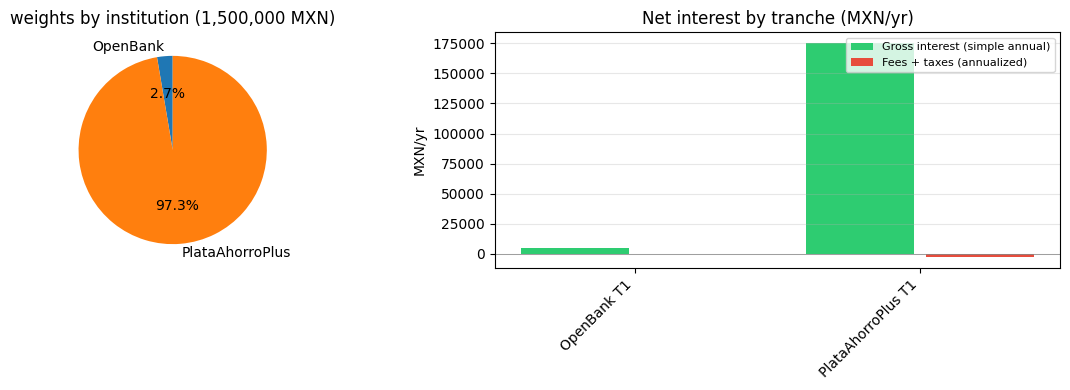

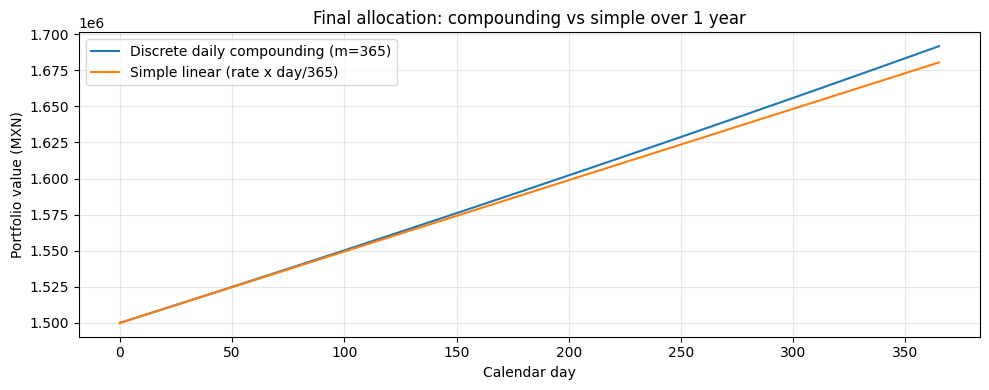

In [13]:
# Edit this value and run
test_amount = 1_500_000
#test_amount = 766_000

result = allocate(total=test_amount, institutions=institutions_ex_nu, horizon_years=1.0, periods_per_year=365)
summarize_and_plot(result, institutions_ex_nu, test_amount, f'Your test: {test_amount:,} MXN')


=== Your test: 40,000 MXN ===
total_allocated: 40,000.00
expected_return: 5,527.03
effective_rate: 13.82%
total_expenses_paid: 12.00
total_taxes_paid: 13.05
total_withholding_paid: 135.00
weights: {'cetes28': ['0.0%'], 'Nu': ['62.5%', '0.0%'], 'OpenBank': ['37.5%', '0.0%', '0.0%'], 'PlataAhorroPlus': ['0.0%'], 'Mifel': ['0.0%', '0.0%', '0.0%']}
allocations: {'cetes28': ['$0'], 'Nu': ['$25,000', '$0'], 'OpenBank': ['$15,000', '$0', '$0'], 'PlataAhorroPlus': ['$0'], 'Mifel': ['$0', '$0', '$0']}
constraint_info: {'Nu': [{'tier_idx': 0, 'type': 'monthly_expense', 'cost': 1.0, 'benefit': 'high_rate_tier', 'activated': True}], 'PlataAhorroPlus': [{'tier_idx': 0, 'type': 'monthly_expense', 'cost': 114.84, 'benefit': 'membership_plan', 'activated': False}]}

Allocation breakdown:
Institution  Tier  Amount Weight (%)   Rate
         Nu     1 $25,000      62.50 13.00%
   OpenBank     1 $15,000      37.50 13.00%


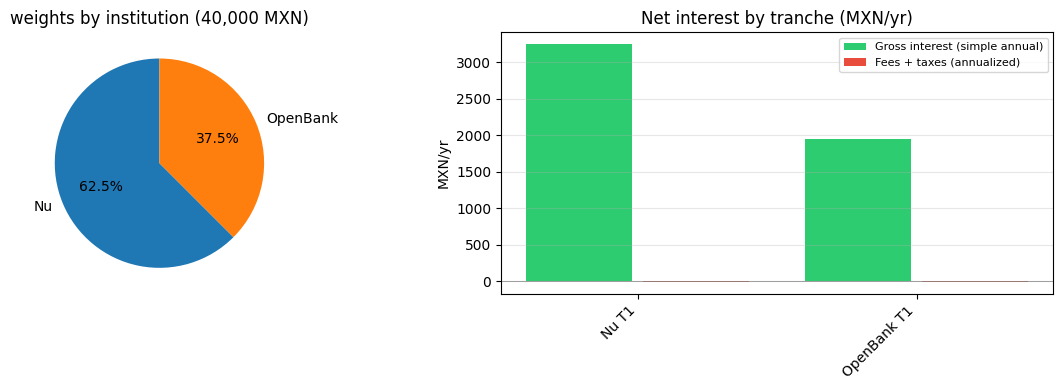

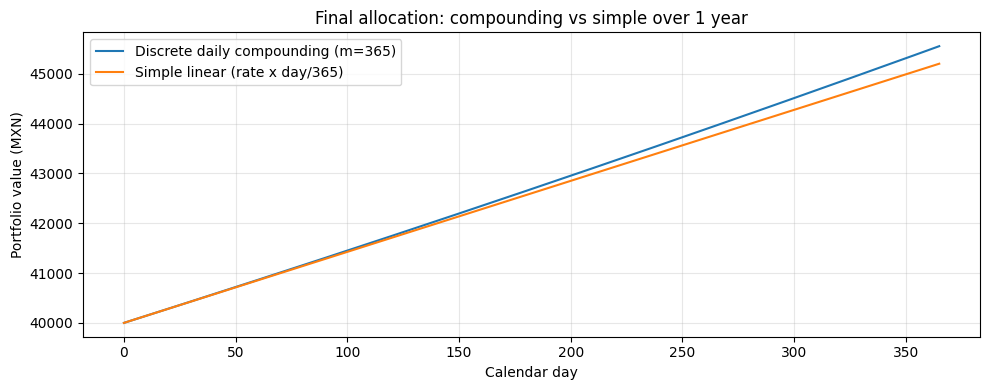

In [14]:
# Edit this value and run
test_amount = 40_000

result = allocate(total=test_amount, institutions=institutions, periods_per_year=365, horizon_years=1)
summarize_and_plot(result, institutions, test_amount, f'Your test: {test_amount:,} MXN')